In [1]:
import os
import clip
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = "cuda"

# --- Load CLIP ---
print("Loading CLIP model...")
model, preprocess = clip.load("ViT-L/14", device=device)
model.eval()
print(f"Using: {torch.cuda.get_device_name(0)}")

Loading CLIP model...
Using: NVIDIA RTX A6000


In [12]:
import os

base_path = "dataset/bffhq/1pct"

class_0_path = os.path.join(base_path, "0")
class_1_path = os.path.join(base_path, "1")

len_0 = len(os.listdir(class_0_path))
len_1 = len(os.listdir(class_1_path))

print("Length of 1pct/0:", len_0)
print("Length of 1pct/1:", len_1)

Length of 1pct/0: 9600
Length of 1pct/1: 9600


In [2]:
# --- Dataset for flat folders (test/valid) ---
class BFFHQFlat(Dataset):
    def __init__(self, folder, transform):
        self.transform = transform
        self.samples = []
        for fname in sorted(os.listdir(folder)):
            if not fname.endswith(".png"):
                continue
            parts = fname.replace(".png", "").split("_")
            age    = int(parts[1])   # 0=young, 1=old    
            gender = int(parts[2])   # 0=female, 1=male
            self.samples.append((os.path.join(folder, fname), age, gender))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, age, gender = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return img, age, gender

# --- Dataset for align/conflict folders (train) ---
class BFFHQTrain(Dataset):
    def __init__(self, folder, transform, subset=None):
        # subset: "align", "conflict", or None (both)
        self.transform = transform
        self.samples = []
        subsets = [subset] if subset else ["align", "conflict"]
        for s in subsets:
            for age_label in ["0", "1"]:
                subdir = os.path.join(folder, s, age_label)
                if not os.path.exists(subdir):
                    continue
                for fname in sorted(os.listdir(subdir)):
                    if not fname.endswith(".png"):
                        continue
                    parts = fname.replace(".png", "").split("_")
                    age    = int(parts[1])   # 0=young, 1=old
                    gender = int(parts[2])   # 0=female, 1=male
                    path   = os.path.join(subdir, fname)
                    self.samples.append((path, age, gender))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, age, gender = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return img, age, gender

In [ ]:
# --- Single extraction function (works for both) ---
def extract(loader):
    all_embs, all_age, all_gender = [], [], []
    with torch.no_grad():
        for imgs, age, gender in loader:
            embs = model.encode_image(imgs.to(device))
            all_embs.append(embs.cpu())
            all_age.append(age)
            all_gender.append(gender)
    return torch.cat(all_embs), torch.cat(all_age).numpy(), torch.cat(all_gender).numpy()



# --- Run extraction ---
base = "dataset/bffhq"

print("Extracting test...")
test_ds  = BFFHQFlat(f"{base}/test", preprocess)
test_embs, test_age, test_gender = extract(DataLoader(test_ds, batch_size=512, num_workers=4))

print("Extracting valid...")
valid_ds  = BFFHQFlat(f"{base}/valid", preprocess)
valid_embs, valid_age, valid_gender = extract(DataLoader(valid_ds, batch_size=512, num_workers=4))

print("Extracting train (1pct)...")
train_ds  = BFFHQTrain(f"{base}/1pct", preprocess)
train_embs, train_age, train_gender = extract(DataLoader(train_ds, batch_size=512, num_workers=4))


# --- Extract align and conflict separately ---
print("Extracting train align (1pct)...")
align_embs, align_age, align_gender = extract(DataLoader(BFFHQTrain("dataset/bffhq/1pct", preprocess, subset="align"),batch_size=512, num_workers=4))

print("Extracting train conflict (1pct)...")
conflict_embs, conflict_age, conflict_gender = extract(DataLoader(BFFHQTrain("dataset/bffhq/1pct", preprocess, subset="conflict"), batch_size=512, num_workers=4))

Extracting test...
Extracting valid...
Extracting train (1pct)...
Extracting train align (1pct)...
Extracting train conflict (1pct)...


In [23]:
# --- Save ---
os.makedirs("embeddings", exist_ok=True)

# test / valid
torch.save(test_embs,  "embeddings/test_embs.pt")
torch.save(valid_embs, "embeddings/valid_embs.pt")
np.save("embeddings/test_age.npy",     test_age)
np.save("embeddings/test_gender.npy",  test_gender)
np.save("embeddings/valid_age.npy",    valid_age)
np.save("embeddings/valid_gender.npy", valid_gender)

# train combined
torch.save(train_embs, "embeddings/train_embs.pt")
np.save("embeddings/train_age.npy",    train_age)
np.save("embeddings/train_gender.npy", train_gender)

# align / conflict separately
torch.save(align_embs,    "embeddings/align_embs.pt")
torch.save(conflict_embs, "embeddings/conflict_embs.pt")
np.save("embeddings/align_age.npy",       align_age)
np.save("embeddings/align_gender.npy",    align_gender)
np.save("embeddings/conflict_age.npy",    conflict_age)
np.save("embeddings/conflict_gender.npy", conflict_gender)

print("All embeddings saved to embeddings/")

All embeddings saved to embeddings/


In [ ]:
# --- Extract 0(young) and 1(old) separately ---
print("Extracting train 0(young) (1pct)...")
young_0_embs, young_0_age, young_0_gender = extract(DataLoader(BFFHQFlat("dataset/bffhq/1pct/0", preprocess),batch_size=512, num_workers=4))

print("Extracting train 1(old) (1pct)...")
old_1_embs, old_1_age, old_1_gender = extract(DataLoader(BFFHQFlat("dataset/bffhq/1pct/1", preprocess), batch_size=512, num_workers=4))

torch.save(young_0_embs,    "embeddings/young_0_embs.pt")
torch.save(old_1_embs, "embeddings/old_1_embs.pt")
np.save("embeddings/young_0_age.npy",       young_0_age)
np.save("embeddings/young_0_gender.npy",    young_0_gender)
np.save("embeddings/old_1_age.npy",    old_1_age)
np.save("embeddings/old_1_gender.npy", old_1_gender)

Extracting train 0(young) (1pct)...
Extracting train 1(old) (1pct)...


In [24]:
# --- Bias check ---
print("\n--- Bias check ---")
for split, age_l, gen_l in [
    ("test",     test_age,     test_gender),
    ("valid",    valid_age,    valid_gender),
    ("train",    train_age,    train_gender),
    ("align",    align_age,    align_gender),
    ("conflict", conflict_age, conflict_gender)
]:
    print(f"\n{split} (n={len(age_l)}):")
    for age, name in [(0, "young"), (1, "old")]:
        mask = age_l == age
        if mask.sum() == 0:
            continue
        male_pct = (gen_l[mask] == 1).mean() * 100
        print(f"  {name}: {male_pct:.1f}% male, {100-male_pct:.1f}% female  (n={mask.sum()})")


--- Bias check ---

test (n=1000):
  young: 50.0% male, 50.0% female  (n=500)
  old: 50.0% male, 50.0% female  (n=500)

valid (n=1000):
  young: 0.0% male, 100.0% female  (n=500)
  old: 100.0% male, 0.0% female  (n=500)

train (n=19200):
  young: 1.0% male, 99.0% female  (n=9600)
  old: 99.0% male, 1.0% female  (n=9600)

align (n=19008):
  young: 0.0% male, 100.0% female  (n=9504)
  old: 100.0% male, 0.0% female  (n=9504)

conflict (n=192):
  young: 100.0% male, 0.0% female  (n=96)
  old: 0.0% male, 100.0% female  (n=96)


In [2]:
import torch
import numpy as np

# Load
train_embs  = torch.load("embeddings/train_embs.pt").float()
test_embs   = torch.load("embeddings/test_embs.pt").float()
valid_embs  = torch.load("embeddings/valid_embs.pt").float()
align_embs  = torch.load("embeddings/align_embs.pt").float()
conflict_embs = torch.load("embeddings/conflict_embs.pt").float()
young_0_embs=torch.load("embeddings/young_0_embs.pt").float()
old_1_embs=torch.load("embeddings/old_1_embs.pt").float()


young_0_age=np.load("embeddings/young_0_age.npy")
young_0_gender=np.load("embeddings/young_0_gender.npy")
old_1_age=np.load("embeddings/old_1_age.npy")
old_1_gender=np.load("embeddings/old_1_gender.npy")
train_age     = np.load("embeddings/train_age.npy")
train_gender  = np.load("embeddings/train_gender.npy")
test_age      = np.load("embeddings/test_age.npy")
test_gender   = np.load("embeddings/test_gender.npy")
valid_age     = np.load("embeddings/valid_age.npy")
valid_gender  = np.load("embeddings/valid_gender.npy")
align_age     = np.load("embeddings/align_age.npy")
align_gender  = np.load("embeddings/align_gender.npy")
conflict_age  = np.load("embeddings/conflict_age.npy")
conflict_gender = np.load("embeddings/conflict_gender.npy")

/tmp/ipykernel_3931836/26409301.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_embs  = torch.load("embeddings/train_embs.pt").float()
/tmp/ipykernel_3931836/26409

In [9]:
print(train_embs.shape)
print(test_embs.shape)
print(valid_embs.shape)
print(align_embs.shape)
print(conflict_embs.shape)
print(young_0_embs.shape)
print(old_1_embs.shape)

torch.Size([19200, 768])
torch.Size([1000, 768])
torch.Size([1000, 768])
torch.Size([19008, 768])
torch.Size([192, 768])
torch.Size([9600, 768])
torch.Size([9600, 768])


In [79]:
print(train_embs[(train_age==1) & (train_gender==1)][0].shape)

torch.Size([768])


In [80]:
# Mean vectors per group (more stable than single samples)
old_male    = train_embs[(train_age==1) & (train_gender==1)].mean(0)
old_female  = train_embs[(train_age==1) & (train_gender==0)].mean(0)
young_male  = train_embs[(train_age==0) & (train_gender==1)].mean(0)
young_female= train_embs[(train_age==0) & (train_gender==0)].mean(0)

def find_nearest(query_vec, embs, age_l, gender_l, top_k=5):
    query_norm = query_vec / query_vec.norm()
    embs_norm  = embs 
    sims       = embs_norm @ query_norm
    topk       = sims.topk(top_k)
    print(f"Top {top_k} nearest:")
    for sim, idx in zip(topk.values, topk.indices):
        a = "old"   if age_l[idx]==1    else "young"
        g = "male"  if gender_l[idx]==1 else "female"
        print(f"  idx={idx.item():5d}  {a} {g:8s}  sim={sim:.3f}")

# --- Try different arithmetic ---

# 1. old male - gender = old female?
print("\n1. old_male - (male - female):")
find_nearest(old_male - (young_male - young_female), train_embs, train_age, train_gender)

# 2. young female + age = old female?
print("\n2. young_female + (old - young):")
find_nearest(young_female + (old_male - young_male), train_embs, train_age, train_gender)

# 3. young male + age = old male?
print("\n3. young_male + (old - young):")
find_nearest(young_male + (old_female - young_female), train_embs, train_age, train_gender)


1. old_male - (male - female):
Top 5 nearest:
  idx= 1267  young female    sim=18.512
  idx= 3155  young female    sim=18.354
  idx= 4697  young female    sim=18.199
  idx= 4631  young female    sim=18.190
  idx=   67  young female    sim=18.173

2. young_female + (old - young):
Top 5 nearest:
  idx= 1267  young female    sim=18.512
  idx= 3155  young female    sim=18.354
  idx= 4697  young female    sim=18.199
  idx= 4631  young female    sim=18.190
  idx=   67  young female    sim=18.173

3. young_male + (old - young):
Top 5 nearest:
  idx=12477  old male      sim=18.783
  idx=15763  old male      sim=18.419
  idx=18942  old male      sim=18.407
  idx=12777  old male      sim=18.391
  idx=15143  old male      sim=18.277


In [72]:
# How far apart are the 4 group mean vectors?
import torch.nn.functional as F

groups = {
    "old_male":    old_male,
    "old_female":  old_female,
    "young_male":  young_male,
    "young_female":young_female,
}

print("Pairwise cosine similarities between group means:")
print(f"{'':15s}", end="")
for n in groups: print(f"{n:15s}", end="")
print()

for n1, v1 in groups.items():
    print(f"{n1:15s}", end="")
    for n2, v2 in groups.items():
        sim = F.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0)).item()
        print(f"{sim:15.3f}", end="")
    print()

Pairwise cosine similarities between group means:
               old_male       old_female     young_male     young_female   
old_male                 1.000          0.894          0.912          0.862
old_female               0.894          1.000          0.867          0.932
young_male               0.912          0.867          1.000          0.918
young_female             0.862          0.932          0.918          1.000


Saved similarity_heatmap.png


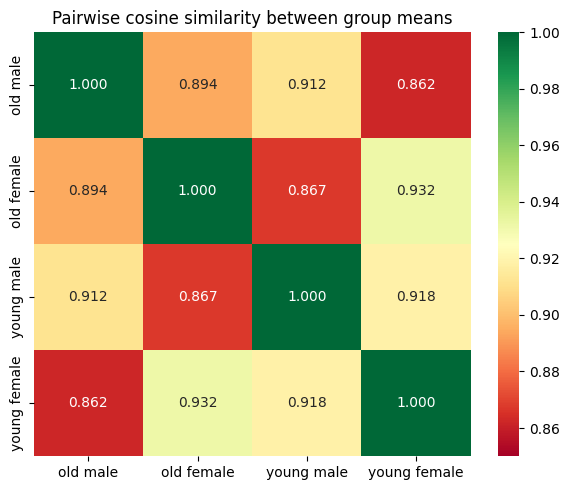

In [74]:
import seaborn as sns

matrix = torch.tensor([
    [1.000, 0.894, 0.912, 0.862],
    [0.894, 1.000, 0.867, 0.932],
    [0.912, 0.867, 1.000, 0.918],
    [0.862, 0.932, 0.918, 1.000],
])

labels = ["old male", "old female", "young male", "young female"]

plt.figure(figsize=(6, 5))
sns.heatmap(matrix.numpy(), annot=True, fmt=".3f",
            xticklabels=labels, yticklabels=labels,
            cmap="RdYlGn", vmin=0.85, vmax=1.0)
plt.title("Pairwise cosine similarity between group means")
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)
print("Saved similarity_heatmap.png")

In [69]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393",      1: "#1A5FA8",    2: "#FF8C00",    3: "#2ECC71"}

splits = [
    ("train",    train_embs.numpy(),    train_age,    train_gender),
    ("test",     test_embs.numpy(),     test_age,     test_gender),
    ("valid",    valid_embs.numpy(),    valid_age,    valid_gender),
    ("align",    align_embs.numpy(),    align_age,    align_gender),
    ("conflict", conflict_embs.numpy(), conflict_age, conflict_gender),
]

for split_name, embs, age, gender in splits:
    np.random.seed(42)
    n=len(embs)
    idx = np.random.choice(len(embs), n, replace=False)
    embs_sub   = embs[idx]
    age_sub    = age[idx]
    gender_sub = gender[idx]
    group_sub  = age_sub * 2 + gender_sub

    print(f"Running t-SNE for {split_name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs_sub)

    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group_sub == g
        if mask.sum() == 0:
            continue
        plt.scatter(e2d[mask, 0], e2d[mask, 1],
                    c=colors[g], label=gname, s=15, alpha=0.7)

    plt.title(f"t-SNE — {split_name} (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"tsne_{split_name}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{split_name}.png")

print("\nAll plots saved!")

Running t-SNE for train (19200 points)...
Saved tsne_train.png
Running t-SNE for test (1000 points)...
Saved tsne_test.png
Running t-SNE for valid (1000 points)...
Saved tsne_valid.png
Running t-SNE for align (19008 points)...
Saved tsne_align.png
Running t-SNE for conflict (192 points)...
Saved tsne_conflict.png

All plots saved!


In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393",      1: "#1A5FA8",    2: "#FF8C00",    3: "#2ECC71"}

splits = [
    ("young_0_embs",    young_0_embs.numpy(),    young_0_age,    young_0_gender),
    ("old_1_embs", old_1_embs.numpy(), old_1_age, old_1_gender),
]

for split_name, embs, age, gender in splits:
    np.random.seed(42)
    n=len(embs)
    idx = np.random.choice(len(embs), n, replace=False)
    embs_sub   = embs[idx]
    age_sub    = age[idx]
    gender_sub = gender[idx]
    group_sub  = age_sub * 2 + gender_sub

    print(f"Running t-SNE for {split_name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs_sub)

    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group_sub == g
        if mask.sum() == 0:
            continue
        plt.scatter(e2d[mask, 0], e2d[mask, 1],
                    c=colors[g], label=gname, s=15, alpha=0.7)

    plt.title(f"t-SNE — {split_name} (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"tsne_{split_name}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{split_name}.png")

print("\nAll plots saved!")

Running t-SNE for young_0_embs (9600 points)...
Saved tsne_young_0_embs.png
Running t-SNE for old_1_embs (9600 points)...
Saved tsne_old_1_embs.png

All plots saved!


Running t-SNE for train (19200 points)...
Running t-SNE for test (1000 points)...
Running t-SNE for valid (1000 points)...
Running t-SNE for align (19008 points)...
Running t-SNE for conflict (192 points)...
Saved tsne_all_splits.png


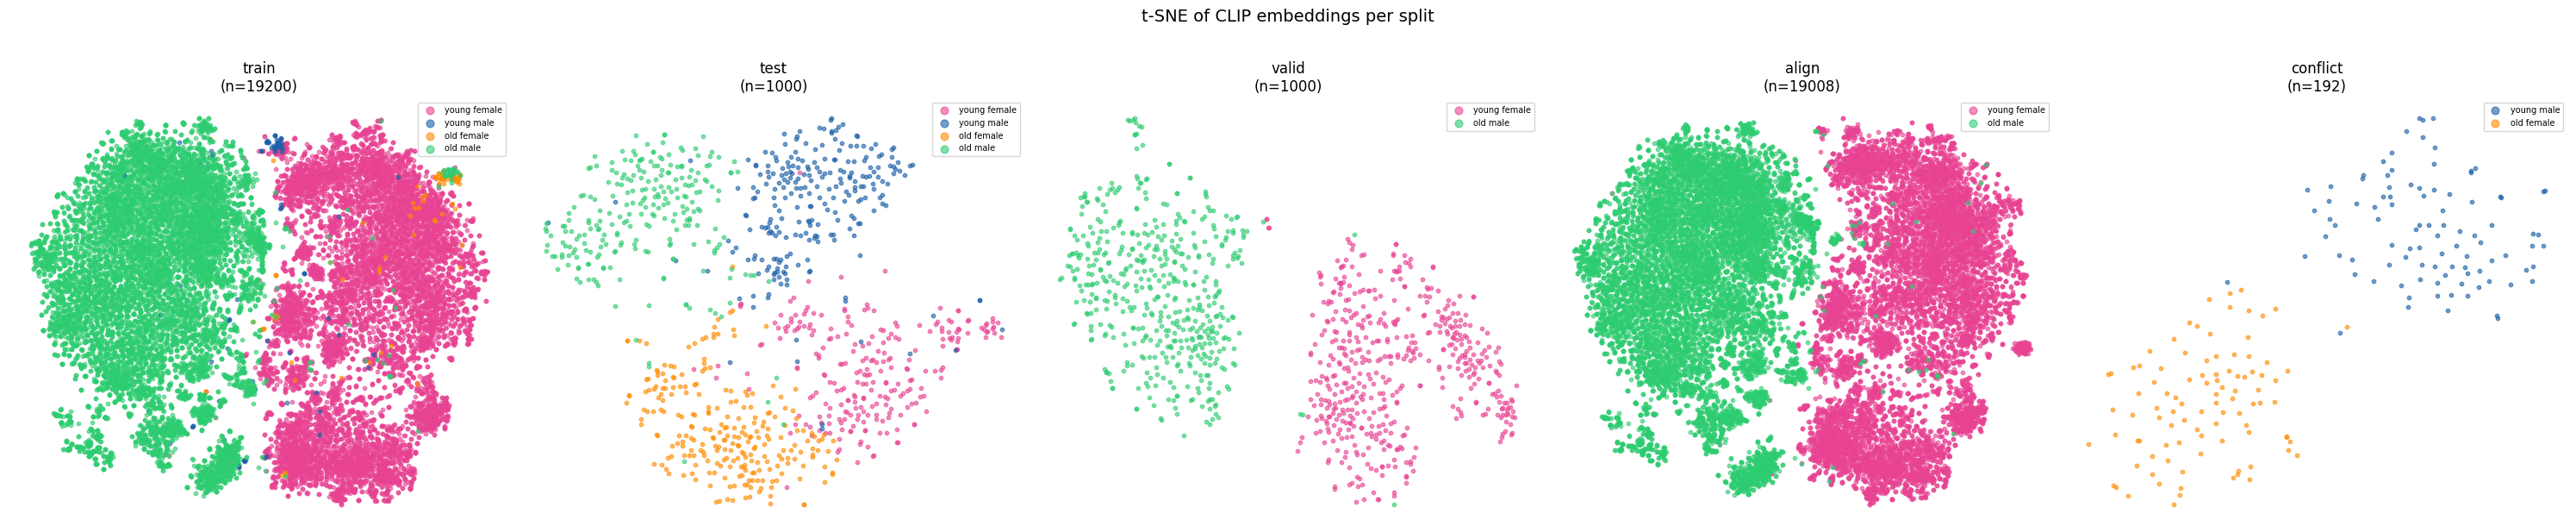

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393",      1: "#1A5FA8",    2: "#FF8C00",    3: "#2ECC71"}

splits = [
    ("train",    train_embs.numpy(),    train_age,    train_gender),
    ("test",     test_embs.numpy(),     test_age,     test_gender),
    ("valid",    valid_embs.numpy(),    valid_age,    valid_gender),
    ("align",    align_embs.numpy(),    align_age,    align_gender),
    ("conflict", conflict_embs.numpy(), conflict_age, conflict_gender),
]

fig, axes = plt.subplots(1, 5, figsize=(30, 6))

for ax, (name, embs, age, gender) in zip(axes, splits):
    np.random.seed(42)
    n = len(embs)
    idx = np.random.choice(len(embs), n, replace=False)
    embs_sub  = embs[idx]
    age_sub   = age[idx]
    gender_sub = gender[idx]
    group_sub  = age_sub * 2 + gender_sub

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs_sub)

    for g, gname in group_names.items():
        mask = group_sub == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=10, alpha=0.6)

    ax.set_title(f"{name}\n(n={n})", fontsize=12)
    ax.legend(fontsize=7, markerscale=2)
    ax.axis("off")

plt.suptitle("t-SNE of CLIP embeddings per split", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("tsne_all_splits.png", dpi=150, bbox_inches="tight")
print("Saved tsne_all_splits.png")

Running t-SNE for train (19200 points)...
Running t-SNE for test (1000 points)...
Running t-SNE for valid (1000 points)...
Running t-SNE for align (19008 points)...
Running t-SNE for conflict (192 points)...
Running t-SNE for old (9600 points)...
Running t-SNE for young (9600 points)...
Saved!


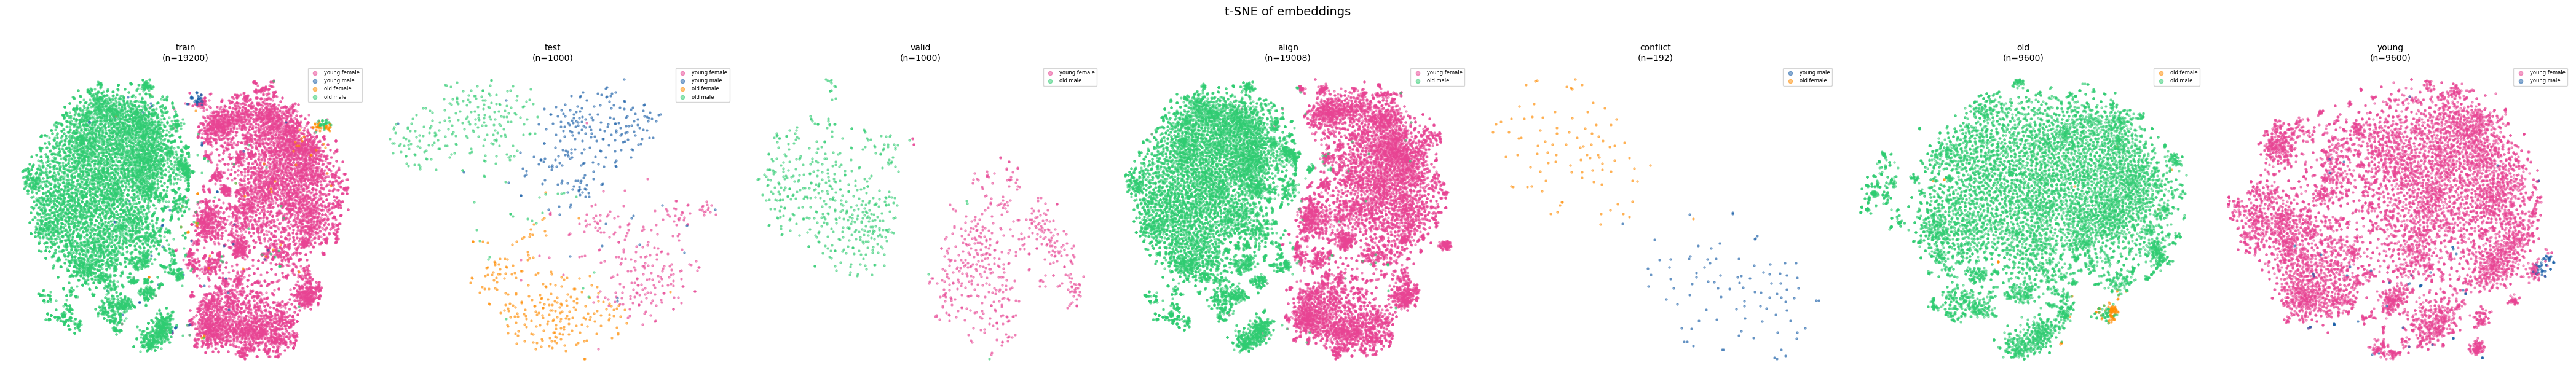

In [40]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}


splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    ("align",    align_embs,     align_age,    align_gender),
    ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]

# 7 splits → 7 subplots
fig, axes = plt.subplots(1, 7, figsize=(42, 6))

for ax, (name, embs, age, gender) in zip(axes, splits):
    group = age * 2 + gender
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

plt.suptitle("t-SNE of embeddings", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("tsne_all_splits_original.png", dpi=150, bbox_inches="tight")
print("Saved!")

# Debiasing Embeddings

In [ ]:
# Check how spread out each group is
for (a, g, name) in [(1,1,"old male"), (1,0,"old female"), 
                      (0,1,"young male"), (0,0,"young female")]:
    mask = (train_age==a) & (train_gender==g)
    group = train_embs[mask]
    print(f"{name:15s}  n={mask.sum():5d}  "
          f"mean_norm={group.norm(dim=-1).mean():.3f}  "
          f"intra_sim={( (group/group.norm(dim=-1,keepdim=True)) @ (group/group.norm(dim=-1,keepdim=True)).T ).mean():.3f}")

old male         n= 9504  mean_norm=18.256  intra_sim=0.606
old female       n=   96  mean_norm=18.836  intra_sim=0.698
young male       n=   96  mean_norm=18.990  intra_sim=0.655
young female     n= 9504  mean_norm=19.363  intra_sim=0.688


In [4]:
# Step 1 — Build bipartite similarity graph
import torch
import numpy as np

# Normalize embeddings
align_norm    = align_embs    / align_embs.norm(dim=-1, keepdim=True)
conflict_norm = conflict_embs / conflict_embs.norm(dim=-1, keepdim=True)

# Similarity matrix between ALL align and conflict samples
# shape: (19008, 192)
sim_matrix = align_norm @ conflict_norm.T
print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"Mean similarity: {sim_matrix.mean():.3f}")
print(f"Max similarity:  {sim_matrix.max():.3f}")



# Step 2 — Find cross-class pairs (align class X ↔ conflict class Y)
# young_female(align) ↔ old_female(conflict)
yf_align_idx    = np.where((align_age==0) & (align_gender==0))[0]  # young female align
of_conflict_idx = np.where((conflict_age==1) & (conflict_gender==0))[0]  # old female conflict

sim_yf_of = sim_matrix[np.ix_(yf_align_idx, of_conflict_idx)]
print(f"\nyoung_female(align) ↔ old_female(conflict)")
print(f"  shape: {sim_yf_of.shape}")
print(f"  mean sim: {sim_yf_of.mean():.3f}")
print(f"  max sim:  {sim_yf_of.max():.3f}")

# old_male(align) ↔ young_male(conflict)
om_align_idx    = np.where((align_age==1) & (align_gender==1))[0]
ym_conflict_idx = np.where((conflict_age==0) & (conflict_gender==1))[0]

sim_om_ym = sim_matrix[np.ix_(om_align_idx, ym_conflict_idx)]
print(f"\nold_male(align) ↔ young_male(conflict)")
print(f"  shape: {sim_om_ym.shape}")
print(f"  mean sim: {sim_om_ym.mean():.3f}")
print(f"  max sim:  {sim_om_ym.max():.3f}")


# young_female(align) ↔ young_male(conflict of same class)
yf_align_idx    = np.where((align_age==0) & (align_gender==0))[0]
ym_conflict_idx = np.where((conflict_age==0) & (conflict_gender==1))[0]

sim_om_ym = sim_matrix[np.ix_(yf_align_idx, ym_conflict_idx)]
print(f"young_female(align) ↔ young_male(conflict of same class)")
print(f"  shape: {sim_om_ym.shape}")
print(f"  mean sim: {sim_om_ym.mean():.3f}")
print(f"  max sim:  {sim_om_ym.max():.3f}")


# old_female(align) ↔ old_male(conflict of same class)
om_align_idx    = np.where((align_age==1) & (align_gender==1))[0]
of_conflict_idx = np.where((conflict_age==1) & (conflict_gender==0))[0]

sim_om_ym = sim_matrix[np.ix_(om_align_idx, of_conflict_idx)]
print(f"old_female(align) ↔ old_male(conflict of same class)")
print(f"  shape: {sim_om_ym.shape}")
print(f"  mean sim: {sim_om_ym.mean():.3f}")
print(f"  max sim:  {sim_om_ym.max():.3f}")

Similarity matrix shape: torch.Size([19008, 192])
Mean similarity: 0.604
Max similarity:  0.938

young_female(align) ↔ old_female(conflict)
  shape: torch.Size([9504, 96])
  mean sim: 0.645
  max sim:  0.938

old_male(align) ↔ young_male(conflict)
  shape: torch.Size([9504, 96])
  mean sim: 0.573
  max sim:  0.925
young_female(align) ↔ young_male(conflict of same class)
  shape: torch.Size([9504, 96])
  mean sim: 0.616
  max sim:  0.926
old_female(align) ↔ old_male(conflict of same class)
  shape: torch.Size([9504, 96])
  mean sim: 0.580
  max sim:  0.916


## Similarity Threshold = 0.8

In [11]:
# Load age-based embeddings

old_embs   = old_1_embs   # all old (male+female)
young_embs = young_0_embs   # all young (male+female)

print(f"old:   {old_embs.shape}")
print(f"young: {young_embs.shape}")

# Normalize
old_norm   = old_embs   / old_embs.norm(dim=-1, keepdim=True)
young_norm = young_embs / young_embs.norm(dim=-1, keepdim=True)

# Similarity matrix old↔young (9600 x 9600)
print("Computing similarity matrix...")
sim_matrix = old_norm @ young_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.80  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

old:   torch.Size([9600, 768])
young: torch.Size([9600, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([9600, 9600])
mean=0.555  max=0.938  min=0.102

Pairs with sim > 0.8: 106127
sim range: 0.800 - 0.938
mean sim of selected pairs: 0.818


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "projection_head(0.8).pt")

Building pairs from 106127 high-sim old↔young pairs...
e1s shape:   torch.Size([106127, 768])
e2s shape:   torch.Size([106127, 768])
weights:     min=0.800  max=0.938
Before training: mean_sim=0.818  std=0.015
Training...
  epoch   0  loss=0.0421  mean_sim=0.176  std=0.026
  epoch  10  loss=0.0001  mean_sim=0.049  std=0.028
  epoch  20  loss=0.0000  mean_sim=0.078  std=0.028
  epoch  30  loss=0.0000  mean_sim=0.070  std=0.028
  epoch  40  loss=0.0000  mean_sim=0.065  std=0.028
Done!


In [ ]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.8: {(sim_before_flat>0.8).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.8: {(sim_after_flat>0.8).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.555  std=0.099  max=0.938  >0.8: 106127
  AFTER:  mean=-0.098  std=0.103  max=0.614  >0.8: 0

W_diff from identity: 0.00139


In [26]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "embeddings/train_proj(0.8).pt")
torch.save(test_proj,  "embeddings/test_proj(0.8).pt")
torch.save(valid_proj, "embeddings/valid_proj(0.8).pt")
print("Saved!")

Saved!


In [ ]:
train_proj=torch.load("embeddings/train_proj(0.8).pt")
test_proj=torch.load("embeddings/test_proj(0.8).pt")
valid_proj=torch.load("embeddings/valid_proj(0.8).pt")

/tmp/ipykernel_3931836/359418744.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("embeddings/train_proj(0.8).pt")
/tmp/ipykernel_3931836/359418744.

In [ ]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3795389/1443157853.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("embeddings/train_proj(0.8).pt")
/tmp/ipykernel_3795389/144315785


  BASELINE
Overall accuracy: 92.0%
  young female  : 100.0%
  young male    : 86.4%
  old female  : 82.8%
  old male    : 98.8%
  worst: 82.8%  best: 100.0%  gap: 17.2%

  DEBIASED (linear push)
Overall accuracy: 91.5%
  young female  : 100.0%
  young male    : 82.8%
  old female  : 83.6%
  old male    : 99.6%
  worst: 82.8%  best: 100.0%  gap: 17.2%


Running t-SNE for train (proj) (19200 points)...


Running t-SNE for test (proj) (1000 points)...
Running t-SNE for valid (proj) (1000 points)...
Running t-SNE for align (proj) (19008 points)...
Running t-SNE for conflict (proj) (192 points)...
Running t-SNE for old (proj) (9600 points)...
Running t-SNE for young (proj) (9600 points)...
Saved!


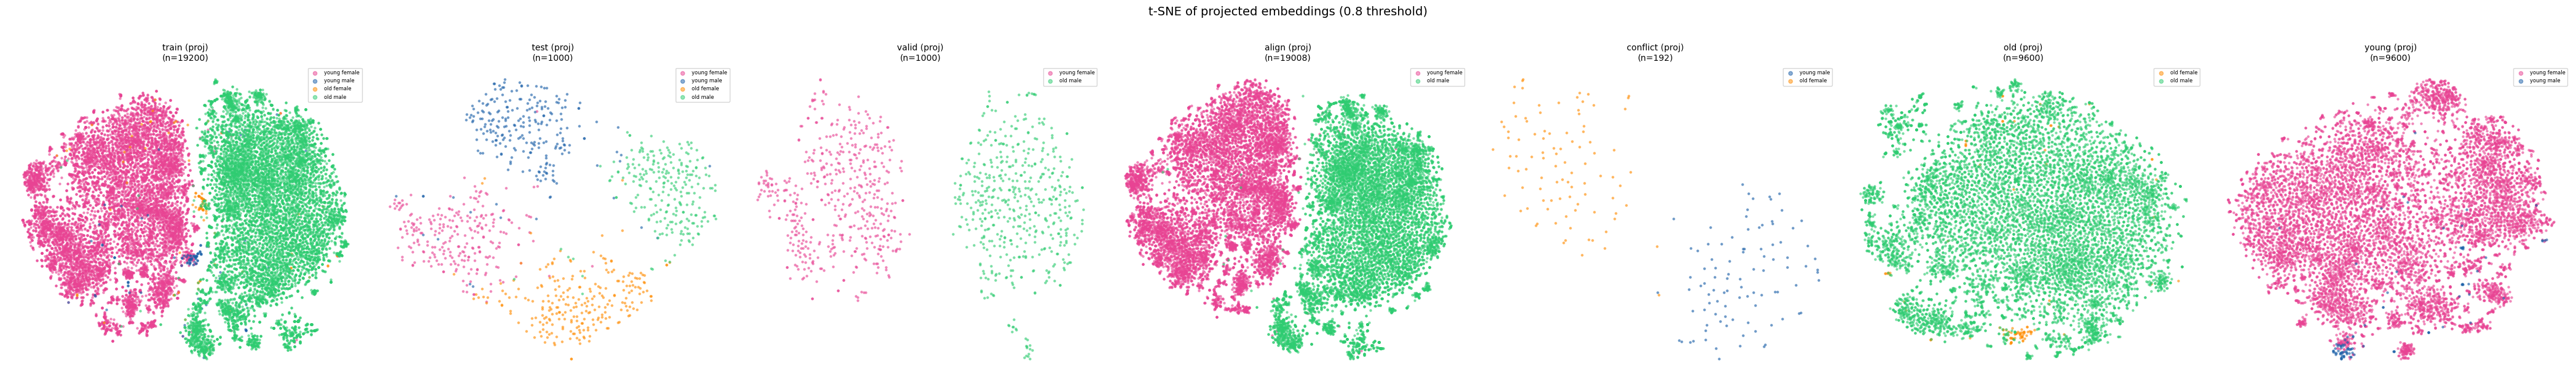

In [41]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",    project(train_embs),    train_age,    train_gender),
    ("test (proj)",     project(test_embs),      test_age,     test_gender),
    ("valid (proj)",    project(valid_embs),     valid_age,    valid_gender),
    ("align (proj)",    project(align_embs),     align_age,    align_gender),
    ("conflict (proj)", project(conflict_embs),  conflict_age, conflict_gender),
    ("old (proj)",      project(old_1_embs),       old_1_age,    old_1_gender),
    ("young (proj)",    project(young_0_embs),     young_0_age,  young_0_gender),
]

# 7 splits → 7 subplots
fig, axes = plt.subplots(1, 7, figsize=(42, 6))

for ax, (name, embs, age, gender) in zip(axes, splits):
    group = age * 2 + gender
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

plt.suptitle("t-SNE of projected embeddings (0.8 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("tsne_projected_all_splits(0.8).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [42]:
model_head.eval()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    ("align",    align_embs,     align_age,    align_gender),
    ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]

for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()   # original
    proj = project(embs_tensor)        # projected

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # Save original
    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0: continue
        plt.scatter(orig_2d[mask, 0], orig_2d[mask, 1],
                    c=colors[g], label=gname, s=5, alpha=0.6)
    plt.title(f"{name} — original (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"tsne_{name}_original.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_original.png")

    # Save projected
    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0: continue
        plt.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
                    c=colors[g], label=gname, s=5, alpha=0.6)
    plt.title(f"{name} — projected (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"tsne_{name}_projected(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_projected(0.8).png")

t-SNE original  train (19200 points)...


t-SNE projected train (19200 points)...
Saved tsne_train_original.png
Saved tsne_train_projected(0.8).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_original.png
Saved tsne_test_projected(0.8).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_original.png
Saved tsne_valid_projected(0.8).png
t-SNE original  align (19008 points)...
t-SNE projected align (19008 points)...
Saved tsne_align_original.png
Saved tsne_align_projected(0.8).png
t-SNE original  conflict (192 points)...
t-SNE projected conflict (192 points)...
Saved tsne_conflict_original.png
Saved tsne_conflict_projected(0.8).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_original.png
Saved tsne_old_projected(0.8).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_original.png
Saved tsne_young_projected(0.8).png


In [43]:
model_head.eval()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    ("align",    align_embs,     align_age,    align_gender),
    ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]

for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0: continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"tsne_{name}_orig_vs_proj(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.8).png")

t-SNE original  train (19200 points)...
t-SNE projected train (19200 points)...
Saved tsne_train_orig_vs_proj(0.8).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_orig_vs_proj(0.8).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_orig_vs_proj(0.8).png
t-SNE original  align (19008 points)...
t-SNE projected align (19008 points)...
Saved tsne_align_orig_vs_proj(0.8).png
t-SNE original  conflict (192 points)...
t-SNE projected conflict (192 points)...
Saved tsne_conflict_orig_vs_proj(0.8).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_orig_vs_proj(0.8).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_orig_vs_proj(0.8).png


## Similarity Threshold = 0.7

In [6]:
old_embs   = old_1_embs   # all old (male+female)
young_embs = young_0_embs   # all young (male+female)

print(f"old:   {old_embs.shape}")
print(f"young: {young_embs.shape}")

# Normalize
old_norm   = old_embs   / old_embs.norm(dim=-1, keepdim=True)
young_norm = young_embs / young_embs.norm(dim=-1, keepdim=True)

# Similarity matrix old↔young (9600 x 9600)
print("Computing similarity matrix...")
sim_matrix = old_norm @ young_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.70  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

old:   torch.Size([9600, 768])
young: torch.Size([9600, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([9600, 9600])


mean=0.555  max=0.938  min=0.102

Pairs with sim > 0.7: 5837491
sim range: 0.700 - 0.938
mean sim of selected pairs: 0.731


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "projection_head(0.7).pt")

Building pairs from 5837491 high-sim old↔young pairs...


e1s shape:   torch.Size([5837491, 768])
e2s shape:   torch.Size([5837491, 768])
weights:     min=0.700  max=0.938
Before training: mean_sim=0.744  std=0.014
Training...
  epoch   0  loss=0.0003  mean_sim=-0.085  std=0.020
  epoch  10  loss=0.0000  mean_sim=-0.185  std=0.015
  epoch  20  loss=0.0000  mean_sim=-0.148  std=0.013
  epoch  30  loss=0.0000  mean_sim=-0.158  std=0.013
  epoch  40  loss=0.0000  mean_sim=-0.161  std=0.012
Done!


In [8]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.7: {(sim_before_flat>0.7).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.7: {(sim_after_flat>0.7).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.555  std=0.099  max=0.938  >0.7: 5837491
  AFTER:  mean=-0.206  std=0.156  max=0.695  >0.7: 0

W_diff from identity: 0.00137


In [9]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "embeddings/train_proj(0.7).pt")
torch.save(test_proj,  "embeddings/test_proj(0.7).pt")
torch.save(valid_proj, "embeddings/valid_proj(0.7).pt")
print("Saved!")

Saved!


In [10]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("embeddings/train_proj(0.7).pt")
test_proj=torch.load("embeddings/test_proj(0.7).pt")
valid_proj=torch.load("embeddings/valid_proj(0.7).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3931836/1416692880.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("embeddings/train_proj(0.7).pt")
/tmp/ipykernel_3931836/141669288


  BASELINE
Overall accuracy: 92.0%
  young female  : 100.0%
  young male    : 86.4%
  old female  : 82.8%
  old male    : 98.8%
  worst: 82.8%  best: 100.0%  gap: 17.2%

  DEBIASED (linear push)
Overall accuracy: 90.8%
  young female  : 100.0%
  young male    : 83.2%
  old female  : 80.8%
  old male    : 99.2%
  worst: 80.8%  best: 100.0%  gap: 19.2%


## Similarity Threshold = 0.9

In [47]:
# Find pairs with similarity > threshold k
k_threshold = 0.90  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")


Pairs with sim > 0.9: 175
sim range: 0.900 - 0.938
mean sim of selected pairs: 0.908


In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "projection_head(0.9).pt")

Building pairs from 175 high-sim old↔young pairs...
e1s shape:   torch.Size([175, 768])
e2s shape:   torch.Size([175, 768])
weights:     min=0.900  max=0.938
Before training: mean_sim=0.908  std=0.013
Training...
  epoch   0  loss=0.3705  mean_sim=0.904  std=0.013
  epoch  10  loss=0.3275  mean_sim=0.855  std=0.015
  epoch  20  loss=0.2810  mean_sim=0.805  std=0.017
  epoch  30  loss=0.2450  mean_sim=0.767  std=0.018
  epoch  40  loss=0.2278  mean_sim=0.750  std=0.019
Done!


In [49]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.9: {(sim_before_flat>0.9).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.9: {(sim_after_flat>0.9).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.555  std=0.099  max=0.938  >0.9: 175
  AFTER:  mean=0.468  std=0.099  max=0.903  >0.9: 1

W_diff from identity: 0.00234


In [50]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "embeddings/train_proj(0.9).pt")
torch.save(test_proj,  "embeddings/test_proj(0.9).pt")
torch.save(valid_proj, "embeddings/valid_proj(0.9).pt")
print("Saved!")

Saved!


In [51]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("embeddings/train_proj(0.9).pt")
test_proj=torch.load("embeddings/test_proj(0.9).pt")
valid_proj=torch.load("embeddings/valid_proj(0.9).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3795389/4159759892.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("embeddings/train_proj(0.9).pt")
/tmp/ipykernel_3795389/415975989


  BASELINE
Overall accuracy: 92.0%
  young female  : 100.0%
  young male    : 86.4%
  old female  : 82.8%
  old male    : 98.8%
  worst: 82.8%  best: 100.0%  gap: 17.2%

  DEBIASED (linear push)
Overall accuracy: 90.5%
  young female  : 100.0%
  young male    : 80.4%
  old female  : 82.0%
  old male    : 99.6%
  worst: 80.4%  best: 100.0%  gap: 19.6%


## Similarity Threshold = 0.75

In [11]:
# Find pairs with similarity > threshold k
k_threshold = 0.75  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")


Pairs with sim > 0.75: 1160714
sim range: 0.750 - 0.938
mean sim of selected pairs: 0.772


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "projection_head(0.75).pt")

Building pairs from 1160714 high-sim old↔young pairs...
e1s shape:   torch.Size([1160714, 768])
e2s shape:   torch.Size([1160714, 768])
weights:     min=0.750  max=0.938
Before training: mean_sim=0.777  std=0.013
Training...
  epoch   0  loss=0.0025  mean_sim=0.057  std=0.025
  epoch  10  loss=0.0000  mean_sim=-0.152  std=0.015
  epoch  20  loss=0.0000  mean_sim=-0.001  std=0.013
  epoch  30  loss=0.0000  mean_sim=-0.208  std=0.014
  epoch  40  loss=0.0000  mean_sim=-0.129  std=0.011
Done!


In [13]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.75: {(sim_before_flat>0.75).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.75: {(sim_after_flat>0.75).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.555  std=0.099  max=0.938  >0.75: 1160714
  AFTER:  mean=-0.304  std=0.171  max=0.867  >0.75: 47

W_diff from identity: 0.00141


In [14]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "embeddings/train_proj(0.75).pt")
torch.save(test_proj,  "embeddings/test_proj(0.75).pt")
torch.save(valid_proj, "embeddings/valid_proj(0.75).pt")
print("Saved!")

Saved!


In [15]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("embeddings/train_proj(0.75).pt")
test_proj=torch.load("embeddings/test_proj(0.75).pt")
valid_proj=torch.load("embeddings/valid_proj(0.75).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3931836/2624811084.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("embeddings/train_proj(0.75).pt")
/tmp/ipykernel_3931836/26248110


  BASELINE
Overall accuracy: 92.0%
  young female  : 100.0%
  young male    : 86.4%
  old female  : 82.8%
  old male    : 98.8%
  worst: 82.8%  best: 100.0%  gap: 17.2%

  DEBIASED (linear push)
Overall accuracy: 90.8%
  young female  : 100.0%
  young male    : 83.6%
  old female  : 80.0%
  old male    : 99.6%
  worst: 80.0%  best: 100.0%  gap: 20.0%


## Similarity Threshold = 0.85

In [16]:
# Find pairs with similarity > threshold k
k_threshold = 0.85  # only push very similar pairs

high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
old_idx, young_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[old_idx, young_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")


Pairs with sim > 0.85: 6507
sim range: 0.850 - 0.938
mean sim of selected pairs: 0.865


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# --- Build pairs ---
print(f"Building pairs from {n_pairs} high-sim old↔young pairs...")

e1s     = old_embs[old_idx]      # old embeddings
e2s     = young_embs[young_idx]  # young embeddings  
weights = sim_vals               # higher sim → push harder

print(f"e1s shape:   {e1s.shape}")
print(f"e2s shape:   {e2s.shape}")
print(f"weights:     min={weights.min():.3f}  max={weights.max():.3f}")

# --- Projection head ---
class ProjectionHead(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, output_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            # nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim),
            # nn.BatchNorm1d(output_dim)
        )
    def forward(self, x):
        out = self.proj(x)
        # return out / out.norm(dim=-1, keepdim=True)
        return out
    
class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        # Initialize as identity — start from CLIP embeddings
        self.W = nn.Parameter(torch.eye(dim))
    
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

# --- Push apart loss weighted by similarity ---
def push_loss(e1, e2, sim_weight, margin=0.5):
    # Normalize ONLY for cosine similarity calculation
    e1_norm = e1 / e1.norm(dim=-1, keepdim=True)
    e2_norm = e2 / e2.norm(dim=-1, keepdim=True)
    sim = F.cosine_similarity(e1_norm, e2_norm)
    
    # Push apart
    push = (sim_weight * torch.clamp(sim - margin, min=0)).mean()
    
    # Over-push penalty
    over_push = torch.clamp(-sim - margin, min=0).mean()
    
    # Std on RAW (unnormalized) outputs
    e1_std = e1.std(dim=0).mean()
    e2_std = e2.std(dim=0).mean()
    std_loss = -0.5 * (e1_std + e2_std)
    
    return push + 0.5 * over_push 
    # return push + 0.5 * over_push + 0.1 * std_loss
    

device     = "cuda"
# model_head = ProjectionHead().to(device)
model_head  = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(e1s, e2s, weights)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)


# Check initial similarity before training
model_head.eval()
with torch.no_grad():
    p1 = model_head(e1s[:1000].to(device))
    p2 = model_head(e2s[:1000].to(device))
    p1n = p1 / p1.norm(dim=-1, keepdim=True)
    p2n = p2 / p2.norm(dim=-1, keepdim=True)
    init_sim = F.cosine_similarity(p1n, p2n).mean().item()
    init_std = torch.cat([p1, p2]).std(dim=0).mean().item()
print(f"Before training: mean_sim={init_sim:.3f}  std={init_std:.3f}")

print("Training...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw in dataloader:
        b_e1 = b_e1.to(device)
        b_e2 = b_e2.to(device)
        b_sw = b_sw.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_loss(proj1, proj2, b_sw)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(e1s[:1000].to(device))
            p2 = model_head(e2s[:1000].to(device))
            p1n = p1 / p1.norm(dim=-1, keepdim=True)
            p2n = p2 / p2.norm(dim=-1, keepdim=True)
            mean_sim = F.cosine_similarity(p1n, p2n).mean().item()
            std_val  = torch.cat([p1, p2]).std(dim=0).mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"mean_sim={mean_sim:.3f}  std={std_val:.3f}")

print("Done!")
torch.save(model_head.state_dict(), "projection_head(0.85).pt")

Building pairs from 6507 high-sim old↔young pairs...
e1s shape:   torch.Size([6507, 768])
e2s shape:   torch.Size([6507, 768])
weights:     min=0.850  max=0.938
Before training: mean_sim=0.863  std=0.014
Training...
  epoch   0  loss=0.2922  mean_sim=0.801  std=0.016
  epoch  10  loss=0.0127  mean_sim=0.384  std=0.027
  epoch  20  loss=0.0036  mean_sim=0.334  std=0.027
  epoch  30  loss=0.0021  mean_sim=0.321  std=0.028
  epoch  40  loss=0.0017  mean_sim=0.317  std=0.028
Done!


In [18]:
model_head.eval()
with torch.no_grad():
    # Project all old and young embeddings
    old_proj   = model_head(old_embs.to(device)).cpu()
    young_proj = model_head(young_embs.to(device)).cpu()
    
    # Recompute similarity matrix on projected embeddings
    old_proj_norm   = old_proj   / old_proj.norm(dim=-1, keepdim=True)
    young_proj_norm = young_proj / young_proj.norm(dim=-1, keepdim=True)
    
    
    sim_after  = old_proj_norm @ young_proj_norm.T
    sim_before =(old_embs / old_embs.norm(dim=-1, keepdim=True)) @ (young_embs / young_embs.norm(dim=-1, keepdim=True)).T

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("Similarity distribution:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  std={sim_before_flat.std():.3f}  "
      f"max={sim_before_flat.max():.3f}  >0.85: {(sim_before_flat>0.85).sum()}")

print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  std={sim_after_flat.std():.3f}  "
      f"max={sim_after_flat.max():.3f}  >0.85: {(sim_after_flat>0.85).sum()}")

# W_diff — how much did the transformation change
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"\nW_diff from identity: {w_diff:.5f}")

Similarity distribution:
  BEFORE: mean=0.555  std=0.099  max=0.938  >0.85: 6507
  AFTER:  mean=-0.069  std=0.177  max=0.806  >0.85: 0

W_diff from identity: 0.00699


In [19]:
model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = model_head(train_embs.to(device)).cpu()
    test_proj  = model_head(test_embs.to(device)).cpu()
    valid_proj = model_head(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "embeddings/train_proj(0.85).pt")
torch.save(test_proj,  "embeddings/test_proj(0.85).pt")
torch.save(valid_proj, "embeddings/valid_proj(0.85).pt")
print("Saved!")

Saved!


In [ ]:
# --- Classifier comparison ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train_proj=torch.load("embeddings/train_proj(0.85).pt")
test_proj=torch.load("embeddings/test_proj(0.85).pt")
valid_proj=torch.load("embeddings/valid_proj(0.85).pt")

def evaluate(train_e, test_e, train_l, test_l, test_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(test_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(test_l, preds)*100:.1f}%")
    
    accs = []
    for age, aname in [(0,"young"),(1,"old")]:
        for gen, gname in [(0,"female"),(1,"male")]:
            mask = (test_l==age) & (test_g==gen)
            if mask.sum()==0: continue
            acc = accuracy_score(test_l[mask], preds[mask])*100
            accs.append(acc)
            print(f"  {aname} {gname:8s}: {acc:.1f}%")
    
    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, test_embs, train_age, test_age, test_gender, "BASELINE")
evaluate(train_proj, test_proj, train_age, test_age, test_gender, "DEBIASED (linear push)")

/tmp/ipykernel_3931836/2195063345.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_proj=torch.load("embeddings/train_proj(0.85).pt")
/tmp/ipykernel_3931836/21950633


  BASELINE
Overall accuracy: 92.0%
  young female  : 100.0%
  young male    : 86.4%
  old female  : 82.8%
  old male    : 98.8%
  worst: 82.8%  best: 100.0%  gap: 17.2%

  DEBIASED (linear push)
Overall accuracy: 92.9%
  young female  : 100.0%
  young male    : 87.2%
  old female  : 85.2%
  old male    : 99.2%
  worst: 85.2%  best: 100.0%  gap: 14.8%


In [25]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "young female", 1: "young male", 2: "old female", 3: "old male"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train",    train_embs,    train_age,    train_gender),
    ("test",     test_embs,      test_age,     test_gender),
    ("valid",    valid_embs,     valid_age,    valid_gender),
    ("align",    align_embs,     align_age,    align_gender),
    ("conflict", conflict_embs,  conflict_age, conflict_gender),
    ("old",      old_1_embs,       old_1_age,    old_1_gender),
    ("young",    young_0_embs,     young_0_age,  young_0_gender),
]


for name, embs_tensor, age, gender in splits:
    n     = len(embs_tensor)
    group = age * 2 + gender

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0: continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"tsne_{name}_orig_vs_proj(0.85).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.85).png")

t-SNE original  train (19200 points)...


t-SNE projected train (19200 points)...
Saved tsne_train_orig_vs_proj(0.85).png
t-SNE original  test (1000 points)...
t-SNE projected test (1000 points)...
Saved tsne_test_orig_vs_proj(0.85).png
t-SNE original  valid (1000 points)...
t-SNE projected valid (1000 points)...
Saved tsne_valid_orig_vs_proj(0.85).png
t-SNE original  align (19008 points)...
t-SNE projected align (19008 points)...
Saved tsne_align_orig_vs_proj(0.85).png
t-SNE original  conflict (192 points)...
t-SNE projected conflict (192 points)...
Saved tsne_conflict_orig_vs_proj(0.85).png
t-SNE original  old (9600 points)...
t-SNE projected old (9600 points)...
Saved tsne_old_orig_vs_proj(0.85).png
t-SNE original  young (9600 points)...
t-SNE projected young (9600 points)...
Saved tsne_young_orig_vs_proj(0.85).png
